# Entraînement PPO

Ce notebook permet de lancer l'entraînement PPO et de visualiser en temps réel l'évolution des métriques.

In [6]:
import sys
sys.path.append('../onitama/')

import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import clear_output

from dl_players_v10 import DensePlayer_v10
from game import GameSession
from players import RandomPlayer, HeuristicPlayer, LookAheadHeuristicPlayer
from ppo import PPOTrainer

%matplotlib inline

## Configuration

In [18]:
PRETRAINED_WEIGHTS = '../saved-models/ppo-sukoshi-e1.weights.h5'
SAVE_PATH = '../saved-models/ppo-sukoshi-e2'

N_ITERATIONS = 750
N_GAMES = 128
N_EPOCHS = 4
MINIBATCH_SIZE = 64
LEARNING_RATE = 1e-4
CLIP_EPSILON = 0.2
VALUE_COEF = 0.50
ENTROPY_COEF = 0.02
GAMMA = 0.99
LAM = 0.95
SAVE_EVERY = 10

# Fréquence de mise à jour des graphiques (toutes les N itérations)
PLOT_EVERY = 1

#Fréquence de réalisation d'un test d'efficience du réseau
EFFICIENCY_EVERY = 10
EFFICIENCY_NB_GAMES = 200




## Initialisation du modèle et du trainer

In [19]:
p1 = DensePlayer_v10()
p1.load_weights(PRETRAINED_WEIGHTS)
p2 = DensePlayer_v10()

p2_alt1 = LookAheadHeuristicPlayer(max_depth=1, heuristic_function="heuristic_defensive")
p2_alt2 = LookAheadHeuristicPlayer(max_depth=2, heuristic_function="heuristic_defensive")
p2_alt3 = LookAheadHeuristicPlayer(max_depth=3, heuristic_function="heuristic_aggressive")

trainer = PPOTrainer(
    player1=p1,
    player2=p2,
    n_games=N_GAMES,
    n_epochs=N_EPOCHS,
    minibatch_size=MINIBATCH_SIZE,
    learning_rate=LEARNING_RATE,
    clip_epsilon=CLIP_EPSILON,
    value_coef=VALUE_COEF,
    entropy_coef=ENTROPY_COEF,
    gamma=GAMMA,
    lam=LAM,
    alternative_players=[p2_alt1, p2_alt2],
    alternative_players_ratio=[20, 30]
)

print("Modèle et trainer initialisés.")

Modèle et trainer initialisés.


## Entraînement avec visualisation en temps réel

**Policy loss**
Ce qu'elle mesure : l'écart entre la nouvelle politique et l'ancienne, pondéré par l'avantage.
Si ratio > 1 : le réseau favorise davantage cette action qu'avant
Si ratio < 1 : le réseau la défavorise
Est ce que le réseau choisit les bonnes actions ?

On surveille ici les anomalies, pas la valeur absolue.
Exemple problème : on reste à 0, ou la valeur explose

**Value loss**
Ce qu'elle mesure : à quel point le réseau se trompe en estimant la valeur d'une position.
Ici on serveille la convergence. Cette valeur doit diminuer. Une valeur stable entre 0.1 et 0.2 serait une bonne mesure. Entre 0.8 et 1 c'est très insable. (Début d'apprentissage)

Itérations   1-20  :  v_loss ≈ 0.8  (le réseau ne sait rien estimer)
Itérations  20-100 :  v_loss ≈ 0.4  (apprentissage en cours)
Itérations 100-500 :  v_loss ≈ 0.1  (régime stable)

Si elle ne descend pas du tout après 50 itérations → value_coef trop faible ou learning_rate trop bas.

Si elle remonte → instabilité, le réseau "désapprend".

**Entropie**
Ce qu'elle mesure : le niveau d'incertitude de la politique. Une entropie élevée = le réseau hésite entre plusieurs coups. Faible = il joue toujours le même coup.
Indicateur critique
Début     : entropy ≈ 4-6   (distribution quasi-uniforme sur ~20 actions valides)
Stable    : entropy ≈ 1-3   (le réseau a des préférences mais explore encore)
Danger    : entropy < 0.5   (trop déterministe)
Collapse  : entropy → 0     (joue toujours le même coup → à arrêter)

La chute doit être progressive. Une chute brutale en 10 itérations signale un problème (souvent entropy_coef trop faible).


**Tableau de bord**
Situation	p_loss	v_loss	entropy	Diagnostic
Entraînement sain	oscille ~0	descend	descend doucement	✓
Réseau bloqué	≈ 0 fixe	stagne	stagne	clip_epsilon trop petit
Explosion	monte	monte	chute	learning_rate trop élevé
Collapse	≈ 0	faible	→ 0	entropy_coef trop faible
Value head ne converge pas	oscille	stagne haut	normale	value_coef trop faible

In [20]:
efficiency_p2 = []
efficiency_p3 = []
efficiency_iters = []

def make_plot_callback(n_iterations, plot_every=1, effencieny_every=1):
    """Retourne un callback qui met à jour les graphiques après chaque itération."""

    def _moving_avg(values, w=10):
        if len(values) < w:
            return None, None
        kernel = np.ones(w) / w
        return list(range(w, len(values) + 1)), np.convolve(values, kernel, mode='valid')

    def plot_callback(iteration, metrics, history):
        if iteration % plot_every != 0 and iteration != n_iterations:
            return
        
        if iteration % effencieny_every == 0:
            #Test d'efficacité
            
            iter = math.floor(iteration/SAVE_EVERY)*SAVE_EVERY
            model_file = PRETRAINED_WEIGHTS
            if iter > 0:
                model_file = f"{SAVE_PATH}_iter{iter}.weights.h5"
            p1_test = DensePlayer_v10()
            p1_test.load_weights(model_file)

            print(f"Test d'efficacité - modèle {model_file}")

            p2 = HeuristicPlayer(heuristic_function="heuristic_defensive")
            gameSession = GameSession(player_one=p1_test, player_two=p2, number_of_games=EFFICIENCY_NB_GAMES)
            gameSession.start()
            stats = gameSession.getStats()
            ratio_p2 = float(stats['p1_win']/EFFICIENCY_NB_GAMES)
            efficiency_p2.append(ratio_p2)

            p3 = LookAheadHeuristicPlayer(heuristic_function="heuristic_defensive", max_depth=2)
            gameSession = GameSession(player_one=p1_test, player_two=p3, number_of_games=EFFICIENCY_NB_GAMES)
            gameSession.start()
            stats = gameSession.getStats()
            ratio_p3 = float(stats['p1_win']/EFFICIENCY_NB_GAMES)
            efficiency_p3.append(ratio_p3)

            efficiency_iters.append(iteration)
            

        iters = list(range(1, iteration + 1))

        clear_output(wait=True)

        fig = plt.figure(figsize=(16, 10))
        fig.suptitle(f'Entraînement PPO — Itération {iteration}/{n_iterations}', fontsize=14, fontweight='bold')
        gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.4, wspace=0.35)

        # --- Policy loss ---
        ax1 = fig.add_subplot(gs[0, 0])
        ax1.plot(iters, history['policy_loss'], color='steelblue', linewidth=1, alpha=0.5)
        iters_s, smooth_pl = _moving_avg(history['policy_loss'])
        if iters_s is not None:
            ax1.plot(iters_s, smooth_pl, color='steelblue', linewidth=2, linestyle='--')
        ax1.set_title('Policy Loss')
        ax1.set_xlabel('Itération')
        ax1.set_ylabel('Loss')
        ax1.grid(True, alpha=0.3)

        # --- Value loss ---
        ax2 = fig.add_subplot(gs[0, 1])
        ax2.plot(iters, history['value_loss'], color='darkorange', linewidth=1, alpha=0.5)
        iters_s, smooth_vl = _moving_avg(history['value_loss'])
        if iters_s is not None:
            ax2.plot(iters_s, smooth_vl, color='darkorange', linewidth=2, linestyle='--')
        ax2.set_title('Value Loss')
        ax2.set_xlabel('Itération')
        ax2.set_ylabel('Loss')
        ax2.grid(True, alpha=0.3)

        # --- Entropie ---
        ax3 = fig.add_subplot(gs[0, 2])
        ax3.plot(iters, history['entropy'], color='seagreen', linewidth=1, alpha=0.5)
        iters_s, smooth_ent = _moving_avg(history['entropy'])
        if iters_s is not None:
            ax3.plot(iters_s, smooth_ent, color='seagreen', linewidth=2, linestyle='--')
        ax3.set_title('Entropie (exploration)')
        ax3.set_xlabel('Itération')
        ax3.set_ylabel('Entropie')
        ax3.grid(True, alpha=0.3)

        # --- Victoires / Défaites / Nuls (empilé) ---
        ax4 = fig.add_subplot(gs[1, 0:2])
        wins = np.array(history['wins'])
        losses = np.array(history['losses'])
        draws = np.array(history['draws'])
        total = wins + losses + draws
        safe_total = np.where(total == 0, 1, total)
        win_pct = wins / safe_total * 100
        loss_pct = losses / safe_total * 100
        draw_pct = draws / safe_total * 100

        ax4.stackplot(iters, win_pct, draw_pct, loss_pct,
                      labels=['Victoires', 'Nuls', 'Défaites'],
                      colors=['#4caf50', '#ff9800', '#f44336'],
                      alpha=0.75)
        ax4.set_title('Résultats des parties (%)')
        ax4.set_xlabel('Itération')
        ax4.set_ylabel('%')
        ax4.set_ylim(0, 100)
        ax4.legend(loc='upper right', fontsize=9)
        ax4.grid(True, alpha=0.2)

        # --- Transitions collectées ---
        ax5 = fig.add_subplot(gs[1, 2])
        ax5.bar(iters, history['transitions'], color='slategray', alpha=0.7, width=0.8)
        ax5.set_title('Transitions collectées')
        ax5.set_xlabel('Itération')
        ax5.set_ylabel('Nombre')
        ax5.grid(True, alpha=0.3, axis='y')

        # --- Efficiency (Heuristic) ---
        ax6 = fig.add_subplot(gs[2, 0])
        ax6.plot(efficiency_iters, efficiency_p2, color='steelblue', linewidth=1.5)
        ax6.set_title('Efficiency (heuristic player [defensive])')
        ax6.set_xlabel('Itération')
        ax6.set_ylabel('Ratio wins')
        ax6.grid(True, alpha=0.3)

        # --- Efficiency (random) ---
        ax7 = fig.add_subplot(gs[2, 1])
        ax7.plot(efficiency_iters, efficiency_p3, color='steelblue', linewidth=1.5)
        ax7.set_title('Efficiency (LookAhead2 euristic player [defensive])')
        ax7.set_xlabel('Itération')
        ax7.set_ylabel('Ratio wins')
        ax7.grid(True, alpha=0.3)

        plt.show()

    return plot_callback

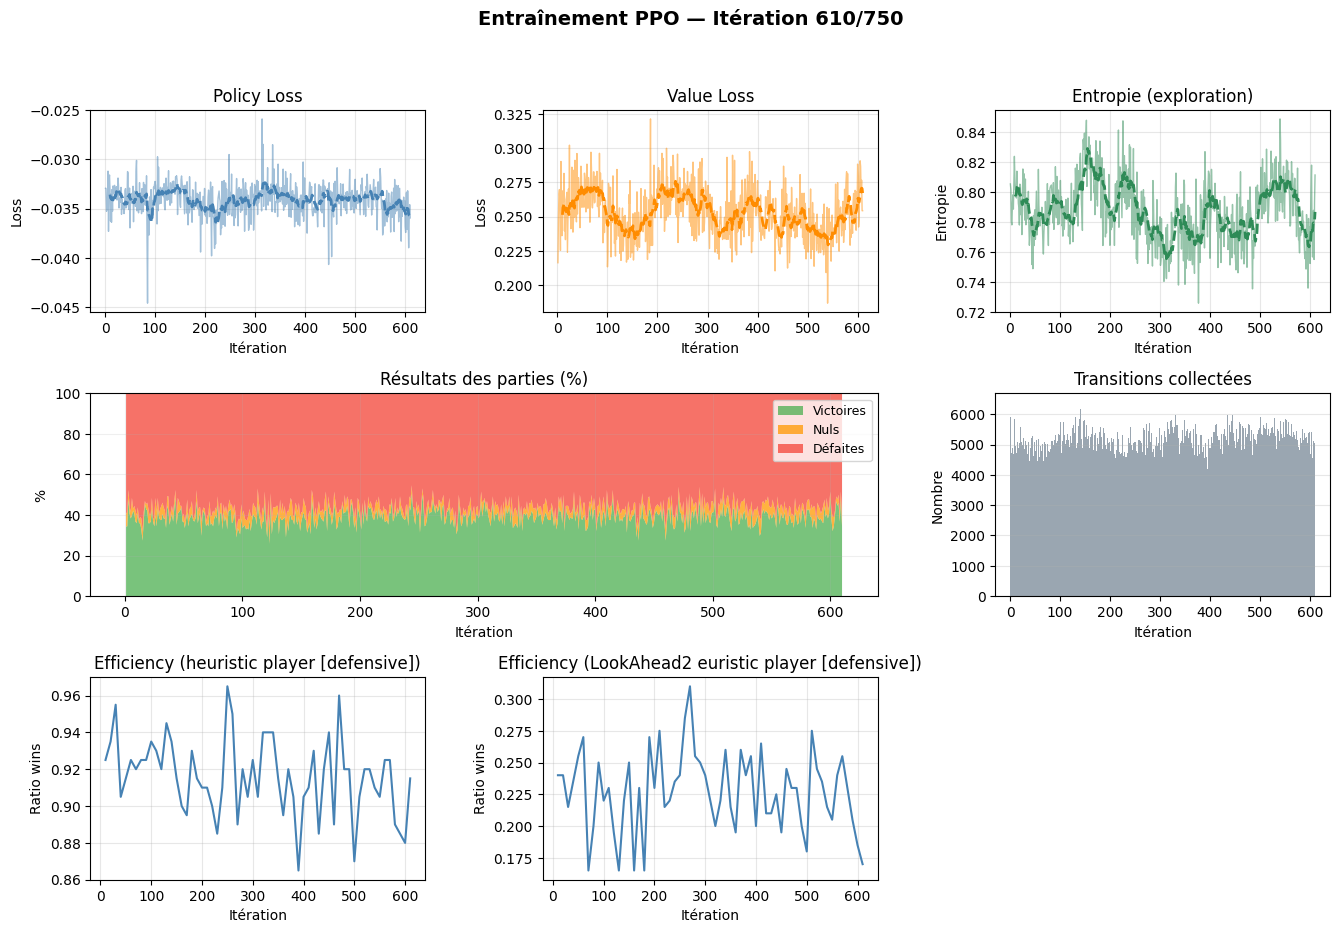

self-play:  33%|███▎      | 42/128 [00:12<00:25,  3.33it/s]


KeyboardInterrupt: 

In [21]:
callback = make_plot_callback(n_iterations=N_ITERATIONS, plot_every=PLOT_EVERY, effencieny_every=EFFICIENCY_EVERY)

history = trainer.train(
    n_iterations=N_ITERATIONS,
    save_every=SAVE_EVERY,
    save_path=SAVE_PATH,
    on_iteration_end=callback
)

print("\nEntraînement terminé !")

## Graphiques finaux (avec lissage)

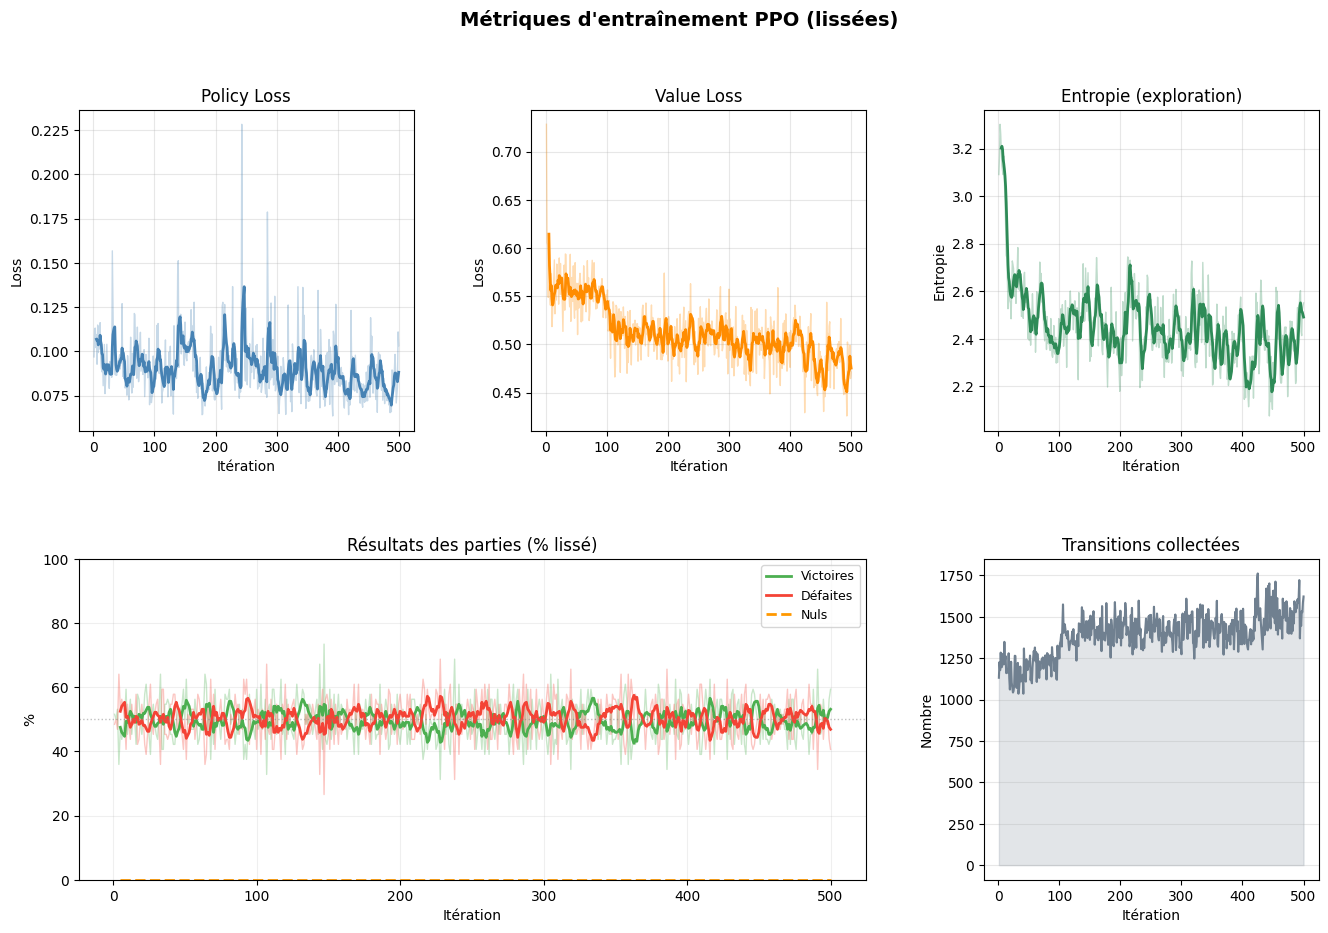

In [ ]:
def smooth(values, window=5):
    """Moyenne glissante."""
    if len(values) < window:
        return values
    kernel = np.ones(window) / window
    return np.convolve(values, kernel, mode='valid')


iters = list(range(1, len(history['policy_loss']) + 1))
w = 5  # Fenêtre de lissage
iters_s = iters[w - 1:]

fig = plt.figure(figsize=(16, 10))
fig.suptitle('Métriques d\'entraînement PPO (lissées)', fontsize=14, fontweight='bold')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# Policy loss
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(iters, history['policy_loss'], color='steelblue', alpha=0.3, linewidth=1)
ax1.plot(iters_s, smooth(history['policy_loss'], w), color='steelblue', linewidth=2)
ax1.set_title('Policy Loss')
ax1.set_xlabel('Itération')
ax1.set_ylabel('Loss')
ax1.grid(True, alpha=0.3)

# Value loss
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(iters, history['value_loss'], color='darkorange', alpha=0.3, linewidth=1)
ax2.plot(iters_s, smooth(history['value_loss'], w), color='darkorange', linewidth=2)
ax2.set_title('Value Loss')
ax2.set_xlabel('Itération')
ax2.set_ylabel('Loss')
ax2.grid(True, alpha=0.3)

# Entropie
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(iters, history['entropy'], color='seagreen', alpha=0.3, linewidth=1)
ax3.plot(iters_s, smooth(history['entropy'], w), color='seagreen', linewidth=2)
ax3.set_title('Entropie (exploration)')
ax3.set_xlabel('Itération')
ax3.set_ylabel('Entropie')
ax3.grid(True, alpha=0.3)

# Win rate lissé
ax4 = fig.add_subplot(gs[1, 0:2])
wins = np.array(history['wins'])
losses = np.array(history['losses'])
draws = np.array(history['draws'])
total = wins + losses + draws
safe_total = np.where(total == 0, 1, total)
win_pct = wins / safe_total * 100
loss_pct = losses / safe_total * 100
draw_pct = draws / safe_total * 100

ax4.plot(iters, win_pct, color='#4caf50', alpha=0.3, linewidth=1)
ax4.plot(iters, loss_pct, color='#f44336', alpha=0.3, linewidth=1)
ax4.plot(iters_s, smooth(win_pct, w), color='#4caf50', linewidth=2, label='Victoires')
ax4.plot(iters_s, smooth(loss_pct, w), color='#f44336', linewidth=2, label='Défaites')
ax4.plot(iters_s, smooth(draw_pct, w), color='#ff9800', linewidth=2, label='Nuls', linestyle='--')
ax4.axhline(50, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax4.set_title('Résultats des parties (% lissé)')
ax4.set_xlabel('Itération')
ax4.set_ylabel('%')
ax4.set_ylim(0, 100)
ax4.legend(loc='upper right', fontsize=9)
ax4.grid(True, alpha=0.2)

# Transitions
ax5 = fig.add_subplot(gs[1, 2])
ax5.plot(iters, history['transitions'], color='slategray', linewidth=1.5)
ax5.fill_between(iters, history['transitions'], alpha=0.2, color='slategray')
ax5.set_title('Transitions collectées')
ax5.set_xlabel('Itération')
ax5.set_ylabel('Nombre')
ax5.grid(True, alpha=0.3, axis='y')

plt.show()

## Résumé statistique

In [ ]:
print("=" * 50)
print("RÉSUMÉ DE L'ENTRAÎNEMENT")
print("=" * 50)
print(f"Itérations       : {len(history['policy_loss'])}")
print(f"Total transitions: {sum(history['transitions'])}")
print()
print("Pertes (moyenne sur les 10 dernières itérations) :")
tail = -10
print(f"  Policy loss : {np.mean(history['policy_loss'][tail:]):.4f}")
print(f"  Value loss  : {np.mean(history['value_loss'][tail:]):.4f}")
print(f"  Entropie    : {np.mean(history['entropy'][tail:]):.4f}")
print()
wins_t = np.array(history['wins'][tail:])
losses_t = np.array(history['losses'][tail:])
draws_t = np.array(history['draws'][tail:])
total_t = wins_t + losses_t + draws_t
safe_t = np.where(total_t == 0, 1, total_t)
print("Résultats (moyenne sur les 10 dernières itérations) :")
print(f"  Win rate  : {(wins_t / safe_t).mean() * 100:.1f}%")
print(f"  Loss rate : {(losses_t / safe_t).mean() * 100:.1f}%")
print(f"  Draw rate : {(draws_t / safe_t).mean() * 100:.1f}%")
print("=" * 50)

RÉSUMÉ DE L'ENTRAÎNEMENT
Itérations       : 500
Total transitions: 695809

Pertes (moyenne sur les 10 dernières itérations) :
  Policy loss : 0.0880
  Value loss  : 0.4709
  Entropie    : 2.5215

Résultats (moyenne sur les 10 dernières itérations) :
  Win rate  : 53.0%
  Loss rate : 47.0%
  Draw rate : 0.0%
